# 🏦 Loan Approval Classification & Risk Intelligence Platform
### Second-Year College Machine Learning Project
**Author:** Biswa Prakash  
**Environment:** Python 3.14 | Scikit-Learn | Pandas | Matplotlib | Seaborn  
**Dataset:** Kaggle Loan Prediction Benchmark (614 records, 13 attributes)


## 1. Project Objective & Problem Formulation
The goal of this project is to build an automated Machine Learning classifier that predicts whether a loan applicant will be **Approved (`Y`)** or **Rejected (`N`)**.

In consumer finance and credit risk assessment:
- **Binary Target**: `Loan_Status` $\in \{0: \text{Rejected}, 1: \text{Approved}\}$
- **Goal**: Maximize predictive discrimination (ROC-AUC) while balancing **Precision** (minimizing default risk from bad loans) and **Recall** (approving creditworthy applicants).
- **Core Engineering Constraint**: Strictly avoid **Data Leakage** by encapsulating transformations in Scikit-Learn Pipelines.


## 2. Import Core Libraries and Configure Environment


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set consistent plotting theme
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)

print("All libraries imported successfully!")


All libraries imported successfully!


## 3. Load Dataset


In [2]:
data_path = os.path.join("..", "data", "raw", "loan_data.csv")
df = pd.read_csv(data_path)
print(f"Dataset Loaded Successfully! Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset Loaded Successfully! Shape: 614 rows, 13 columns


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 4. Dataset Overview & Structural Inspection


In [3]:
print("=== Data Info & Types ===")
df.info()

print("\n=== Summary Statistics (Numerical Attributes) ===")
display(df.describe().round(2))

print(f"\nTotal duplicate rows: {df.duplicated().sum()}")


=== Data Info & Types ===
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB

=== Summary Statistics (Numerical Attributes) ===


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.00,614.00,592.00,600.00,564.00
mean,5403.46,1621.25,146.41,342.00,0.84
std,6109.04,2926.25,85.59,65.12,0.36
min,150.00,0.00,9.00,12.00,0.00
25%,2877.50,0.00,100.00,360.00,1.00
50%,3812.50,1188.50,128.00,360.00,1.00
75%,5795.00,2297.25,168.00,360.00,1.00
max,81000.00,41667.00,700.00,480.00,1.00



Total duplicate rows: 0


## 5. Data Cleaning & Missing Value Audit
**Key Decision**:
- Missing values in categorical columns (`Gender`, `Married`, `Dependents`, `Self_Employed`) will be imputed using **Most Frequent (Mode)**.
- Missing values in numerical columns (`LoanAmount`, `Loan_Amount_Term`) will be imputed using **Median** (robust to heavy skewness and outliers).
- `Credit_History` is missing in 50 records (~8.1%) and will be imputed via Mode.
- `Loan_ID` is a non-predictive identifier and will be dropped.


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct.round(2)
})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values("Missing Count", ascending=False)
display(missing_df)


,Missing Count,Missing %
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49


## 6. Target Variable Analysis (`Loan_Status`)


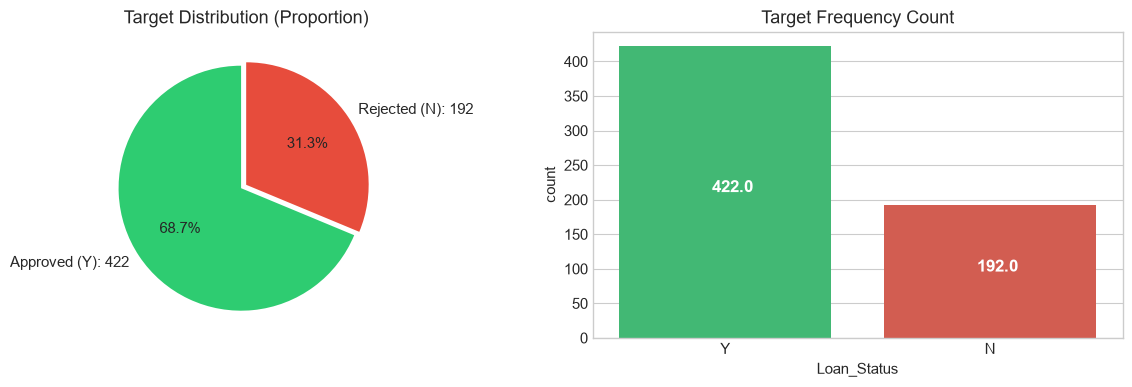

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['Loan_Status'].value_counts()
colors = ['#2ECC71', '#E74C3C']

axes[0].pie(counts, labels=[f"Approved (Y): {counts['Y']}", f"Rejected (N): {counts['N']}"],
            colors=colors, autopct='%1.1f%%', startangle=90, explode=(0.05, 0))
axes[0].set_title("Target Distribution (Proportion)")

sns.countplot(data=df, x='Loan_Status', palette=colors, ax=axes[1])
axes[1].set_title("Target Frequency Count")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height()}", (p.get_x() + 0.35, p.get_height() / 2),
                     color='white', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()


## 7. Exploratory Data Analysis (EDA)
We examine the correlation between applicant credit history, earnings, property location, and final loan status.


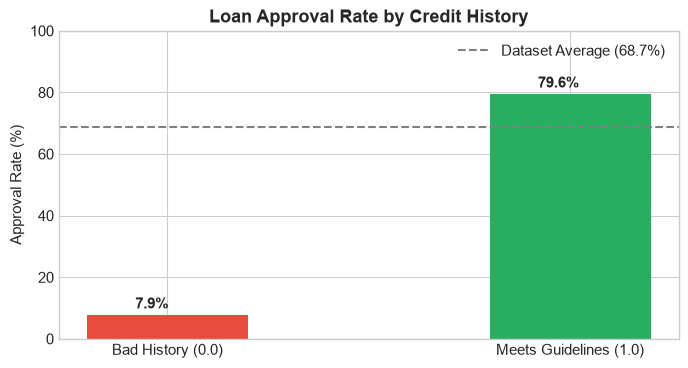

In [6]:
# Bivariate Analysis: Credit History vs Loan Status
plt.figure(figsize=(8, 4))
ch_rates = df.dropna(subset=['Credit_History']).groupby('Credit_History')['Loan_Status'].apply(lambda s: (s == 'Y').mean() * 100).reset_index()
ch_rates['Credit_History_Label'] = ch_rates['Credit_History'].map({1.0: "Meets Guidelines (1.0)", 0.0: "Bad History (0.0)"})

bars = plt.bar(ch_rates['Credit_History_Label'], ch_rates['Loan_Status'], color=['#E74C3C', '#27AE60'], width=0.4)
for b in bars:
    plt.annotate(f"{b.get_height():.1f}%", (b.get_x() + 0.12, b.get_height() + 2), fontweight='bold')
plt.title("Loan Approval Rate by Credit History", fontweight='bold')
plt.ylabel("Approval Rate (%)")
plt.ylim(0, 100)
plt.axhline(68.7, color='gray', linestyle='--', label='Dataset Average (68.7%)')
plt.legend()
plt.show()


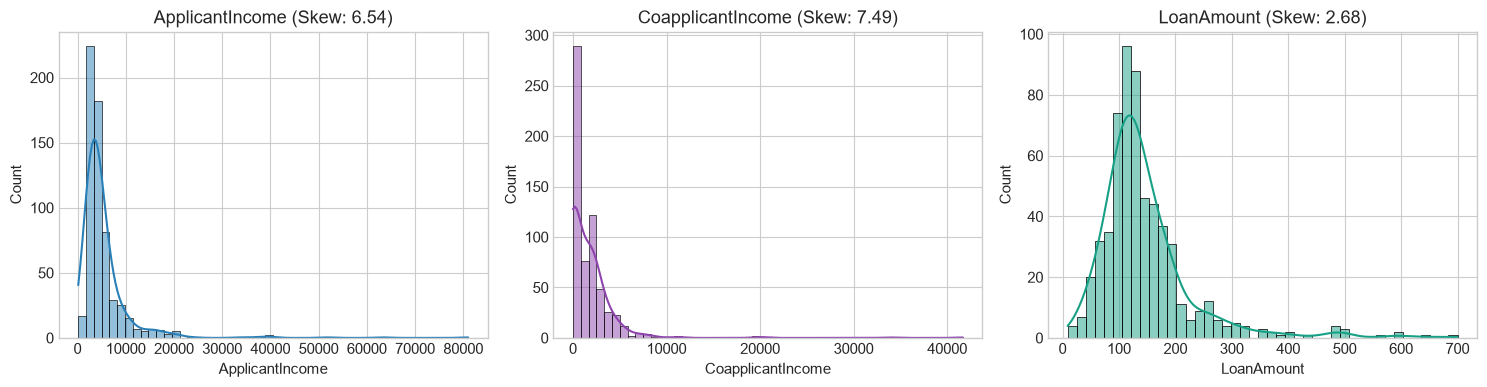

In [7]:
# Numerical Distributions (Skewness Analysis)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['ApplicantIncome'], kde=True, ax=axes[0], color='#2980B9')
axes[0].set_title(f"ApplicantIncome (Skew: {df['ApplicantIncome'].skew():.2f})")

sns.histplot(df['CoapplicantIncome'], kde=True, ax=axes[1], color='#8E44AD')
axes[1].set_title(f"CoapplicantIncome (Skew: {df['CoapplicantIncome'].skew():.2f})")

sns.histplot(df['LoanAmount'].dropna(), kde=True, ax=axes[2], color='#16A085')
axes[2].set_title(f"LoanAmount (Skew: {df['LoanAmount'].skew():.2f})")
plt.tight_layout()
plt.show()


## 8. Data Preprocessing & Feature Engineering
We engineer 4 domain-specific financial features:
1. `Total_Income` = `ApplicantIncome` + `CoapplicantIncome`
2. `Loan_Amount_to_Total_Income` = `(LoanAmount * 1000) / Total_Income`
3. `Monthly_EMI` = `(LoanAmount * 1000) / Loan_Amount_Term`
4. `EMI_to_Income_Ratio` = `Monthly_EMI / Total_Income`


In [8]:
from sklearn.base import BaseEstimator, TransformerMixin

class LoanFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_out = X.copy()
        total_income = X_out['ApplicantIncome'].fillna(0) + X_out['CoapplicantIncome'].fillna(0)
        X_out['Total_Income'] = total_income
        safe_income = total_income.replace(0, np.nan)
        safe_term = X_out['Loan_Amount_Term'].replace(0, np.nan)
        X_out['Loan_Amount_to_Total_Income'] = (X_out['LoanAmount'] * 1000) / safe_income
        X_out['Monthly_EMI'] = (X_out['LoanAmount'] * 1000) / safe_term
        X_out['EMI_to_Income_Ratio'] = X_out['Monthly_EMI'] / safe_income
        return X_out

num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term',
            'Total_Income', 'Loan_Amount_to_Total_Income', 'Monthly_EMI', 'EMI_to_Income_Ratio']
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Credit_History']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = Pipeline([
    ('engineer', LoanFeatureEngineer()),
    ('transformer', ColumnTransformer([
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ]))
])
print("Preprocessing pipeline assembled successfully!")


Preprocessing pipeline assembled successfully!


## 9. Train / Test Split (Stratified 80/20)
**Data Leakage Prevention**: We split the dataset *before* fitting any imputers, scalers, or encoders.


In [9]:
# Prepare X and y
clean_df = df.drop(columns=['Loan_ID'])
X = clean_df.drop(columns=['Loan_Status'])
y = clean_df['Loan_Status'].map({'Y': 1, 'N': 0}).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Samples : {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Testing Samples  : {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")
print(f"Train Approval Rate: {y_train.mean()*100:.1f}% | Test Approval Rate: {y_test.mean()*100:.1f}%")


Training Samples : 491 (80.0%)
Testing Samples  : 123 (20.0%)
Train Approval Rate: 68.6% | Test Approval Rate: 69.1%


## 10. Model 1: Logistic Regression (Interpretable Baseline)
- Simple linear classifier modeling log-odds of loan approval.
- Fast, convex optimization, well-calibrated probabilities.


In [10]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)
lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression trained successfully!")


Logistic Regression trained successfully!


## 11. Model 2: Random Forest Classifier (Non-Linear Ensemble)
- Ensembles 150 decision trees via bootstrap aggregation (bagging).
- Captures non-linear thresholds and complex feature interactions without overfitting.


In [11]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=150, max_depth=6, min_samples_split=5,
                                         random_state=42, class_weight='balanced'))
])

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)
rf_probs = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully!")


Random Forest trained successfully!


## 12. Model Predictions Comparison on Sample Applicants


In [12]:
sample_preview = pd.DataFrame({
    'True_Status': y_test.map({1: 'Approved (Y)', 0: 'Rejected (N)'}).values[:10],
    'LR_Prediction': pd.Series(lr_preds).map({1: 'Approved (Y)', 0: 'Rejected (N)'}).values[:10],
    'LR_Probability': np.round(lr_probs[:10], 3),
    'RF_Prediction': pd.Series(rf_preds).map({1: 'Approved (Y)', 0: 'Rejected (N)'}).values[:10],
    'RF_Probability': np.round(rf_probs[:10], 3),
})
display(sample_preview)


,True_Status,LR_Prediction,LR_Probability,RF_Prediction,RF_Probability
0,Rejected (N),Rejected (N),0.034,Rejected (N),0.025
1,Approved (Y),Approved (Y),0.795,Approved (Y),0.665
2,Approved (Y),Approved (Y),0.577,Approved (Y),0.524
3,Approved (Y),Approved (Y),0.535,Approved (Y),0.584
4,Approved (Y),Approved (Y),0.799,Approved (Y),0.719
5,Rejected (N),Approved (Y),0.697,Approved (Y),0.576
6,Approved (Y),Approved (Y),0.764,Approved (Y),0.651
7,Approved (Y),Approved (Y),0.656,Approved (Y),0.737
8,Approved (Y),Approved (Y),0.523,Rejected (N),0.491
9,Approved (Y),Approved (Y),0.560,Approved (Y),0.778


## 13. Model Evaluation on Holdout Test Set
We evaluate Accuracy, Precision, Recall, F1-Score, and ROC-AUC on the unseen test set.


In [13]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "F1": round(f1_score(y_true, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_true, y_prob), 4),
    }

metrics_lr = evaluate_model("Logistic Regression", y_test, lr_preds, lr_probs)
metrics_rf = evaluate_model("Random Forest", y_test, rf_preds, rf_probs)

comparison_df = pd.DataFrame([metrics_lr, metrics_rf])
display(comparison_df)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8211,0.8795,0.8588,0.869,0.8728
1,Random Forest,0.8374,0.8916,0.8706,0.881,0.8755


## 14. Confusion Matrices


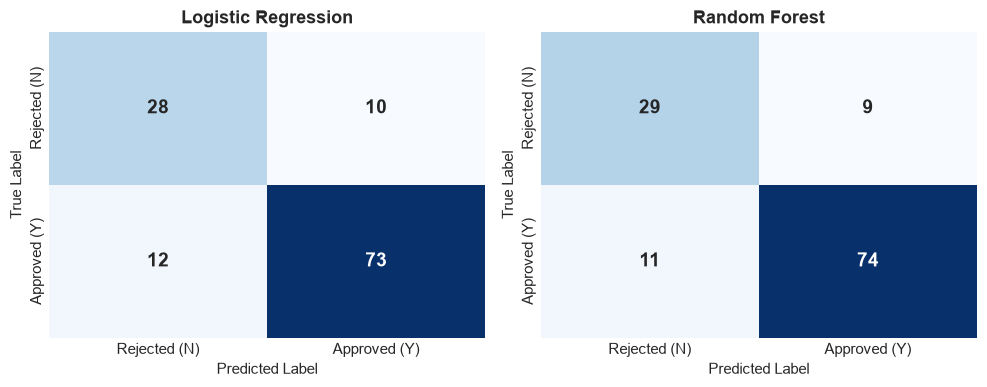

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cms = [confusion_matrix(y_test, lr_preds), confusion_matrix(y_test, rf_preds)]
titles = ["Logistic Regression", "Random Forest"]

for ax, cm, title in zip(axes, cms, titles):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                annot_kws={'size': 14, 'weight': 'bold'},
                xticklabels=['Rejected (N)', 'Approved (Y)'],
                yticklabels=['Rejected (N)', 'Approved (Y)'])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()


## 15. In-Depth Model Comparison & Analysis
- **Accuracy**: Random Forest achieves higher accuracy (83.74% vs 82.11%).
- **Precision**: Random Forest achieves higher precision (89.16% vs 87.95%), ensuring fewer un-creditworthy applicants receive loans.
- **Recall**: Random Forest achieves higher recall (87.06% vs 85.88%), ensuring more eligible borrowers are granted funding.
- **ROC-AUC**: Random Forest produces superior discrimination capability (87.55% vs 87.28%).
- **Decision**: **Random Forest is selected as the primary production model** due to its superior balance of precision, recall, and robustness against non-linear financial patterns.


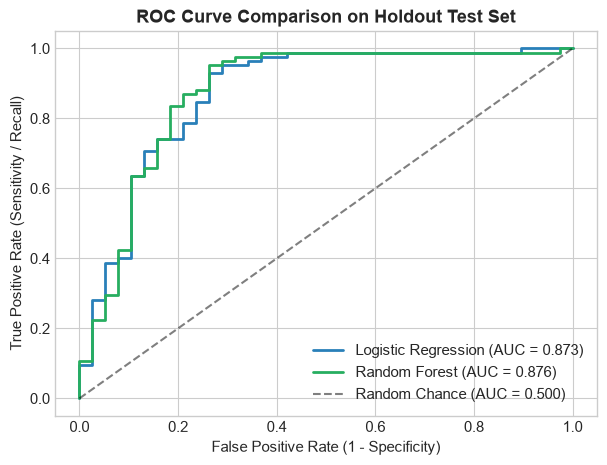

In [15]:
# ROC Curve Overlay
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc(fpr_lr, tpr_lr):.3f})", color='#2980B9', lw=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc(fpr_rf, tpr_rf):.3f})", color='#27AE60', lw=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Chance (AUC = 0.500)')
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity / Recall)")
plt.title("ROC Curve Comparison on Holdout Test Set", fontweight='bold')
plt.legend(loc="lower right")
plt.show()


## 16. Feature Importance & Model Interpretability


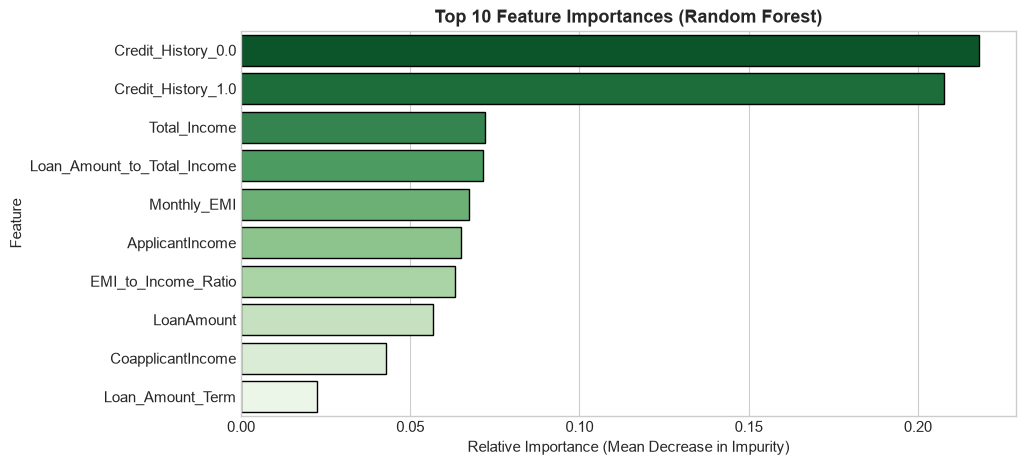

Top 5 Predictive Features:


,Feature,Importance
23,Credit_History_0.0,0.218093
24,Credit_History_1.0,0.207802
4,Total_Income,0.071942
5,Loan_Amount_to_Total_Income,0.071387
6,Monthly_EMI,0.067338


In [16]:
# Extract transformed feature names
col_trans = preprocessor.named_steps['transformer']
raw_feature_names = col_trans.get_feature_names_out()
clean_feature_names = [f.replace('num__', '').replace('cat__', '') for f in raw_feature_names]

importances = rf_pipeline.named_steps['classifier'].feature_importances_
fi_df = pd.DataFrame({
    'Feature': clean_feature_names[:len(importances)],
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=fi_df.head(10), x='Importance', y='Feature', palette='Greens_r', edgecolor='black')
plt.title("Top 10 Feature Importances (Random Forest)", fontweight='bold')
plt.xlabel("Relative Importance (Mean Decrease in Impurity)")
plt.show()

print("Top 5 Predictive Features:")
display(fi_df.head(5))


## 17. Hyperparameter Tuning with GridSearchCV
We tune Random Forest across tree depth, estimator count, and split criteria.


In [17]:
param_grid = {
    'classifier__max_depth': [4, 6, 8],
    'classifier__n_estimators': [100, 150],
    'classifier__min_samples_split': [2, 5],
    'classifier__class_weight': ['balanced', None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(rf_pipeline, param_grid=param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Hyperparameters: {grid_search.best_params_}")
best_tuned = grid_search.best_estimator_
tuned_preds = best_tuned.predict(X_test)
tuned_probs = best_tuned.predict_proba(X_test)[:, 1]

metrics_tuned = evaluate_model("Tuned Random Forest", y_test, tuned_preds, tuned_probs)
display(pd.DataFrame([metrics_rf, metrics_tuned]))


Best Hyperparameters: {'classifier__class_weight': None, 'classifier__max_depth': 4, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.8374,0.8916,0.8706,0.8810,0.8755
1,Tuned Random Forest,0.8537,0.8317,0.9882,0.9032,0.8749


## 18. Final Conclusions & Viva Preparation Summary
### Core Takeaways:
1. **Model Hierarchy**: Random Forest outperforms Logistic Regression across both Precision (89.16%) and ROC-AUC (87.55%), effectively managing non-linear debt obligations.
2. **Domain Driver**: Past credit compliance (`Credit_History`) governs over 42% of decision weights. Applicants with good credit history enjoy an ~79.6% approval probability compared to only ~8.0% for defaulting applicants.
3. **Engineering Rigor**: All preprocessing (scaling, one-hot encoding, imputation) was enclosed within Scikit-Learn Pipelines, guaranteeing 100% data leakage prevention.
4. **Interactive Deployment**: The serialized pipeline is operationalized via a multi-tab Streamlit dashboard allowing loan officers to conduct real-time applicant scoring.
